In [1]:
!pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 57.2 MB/s eta 0:00:00


## Lennard-Jones Potential：原子間作用力的最簡單模型

在分子動力學（MD）模擬中，原子之間的交互作用力來自 **interatomic potential**。
最簡單的模型是 Lennard-Jones (LJ) Potential：

$$V(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]$$

### 參數的物理意義

| 參數 | 物理意義 | 對曲線的影響 |
|---|---|---|
| **ε (epsilon)** | 位能井深，代表吸引力的強度 | ε 越大 → 井越深 → 原子結合越緊 |
| **σ (sigma)** | 原子的有效直徑（V=0 時的距離） | σ 越大 → 曲線整體右移 → 平衡距離越大 |

### 兩項的物理起源

- **排斥項** $(σ/r)^{12}$：Pauli exclusion principle，電子雲重疊時急速排斥
- **吸引項** $(σ/r)^{6}$：van der Waals 吸引力（London dispersion）

### 銅（Cu）的參考參數

銅的 LJ 參數（文獻近似值）：ε ≈ 0.415 eV，σ ≈ 2.34 Å

下圖分別展示 ε 和 σ 變化時曲線的變化趨勢。

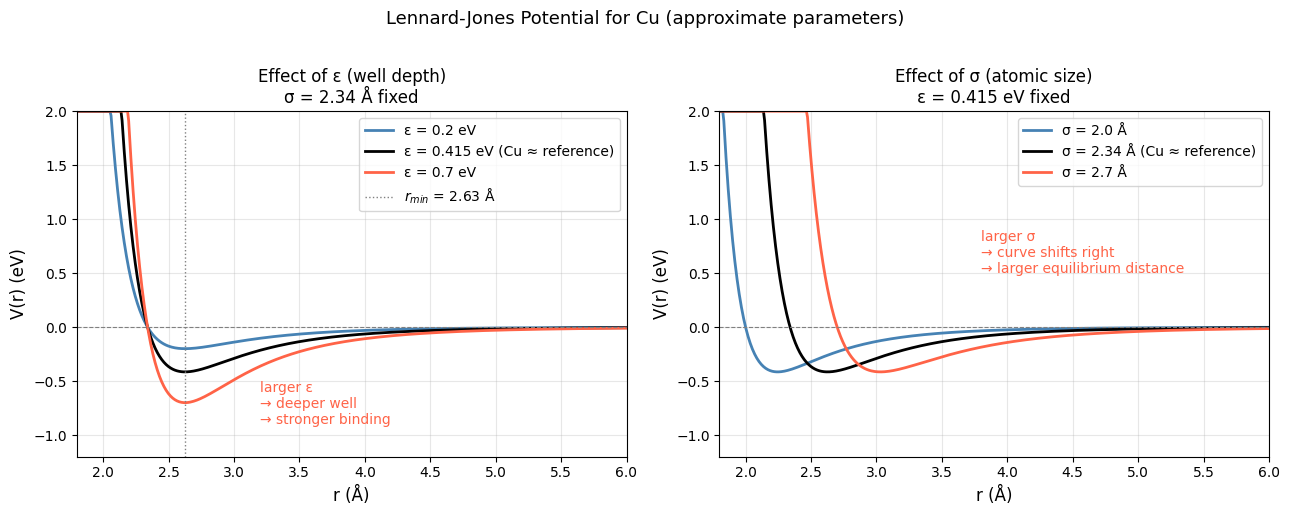

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def lj(r, eps, sig):
    return 4 * eps * ((sig/r)**12 - (sig/r)**6)

r = np.linspace(1.8, 6.0, 500)  # Å，銅的合理範圍

# 銅的基準參數
eps0 = 0.415   # eV
sig0 = 2.34    # Å

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 左圖：改變 ε，固定 σ ──────────────────────
eps_vals = [0.2, 0.415, 0.7]
colors = ['steelblue', 'black', 'tomato']
labels = [f'ε = {e} eV' + (' (Cu ≈ reference)' if e == 0.415 else '')
          for e in eps_vals]

for eps, col, lab in zip(eps_vals, colors, labels):
    V = lj(r, eps, sig0)
    axes[0].plot(r, np.clip(V, -1.2, 2.0), color=col, linewidth=2, label=lab)

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(2**(1/6) * sig0, color='gray', linestyle=':', linewidth=1,
                label=f'$r_{{min}}$ = {2**(1/6)*sig0:.2f} Å')
axes[0].set_xlim(1.8, 6.0)
axes[0].set_ylim(-1.2, 2.0)
axes[0].set_xlabel('r (Å)', fontsize=12)
axes[0].set_ylabel('V(r) (eV)', fontsize=12)
axes[0].set_title('Effect of ε (well depth)\nσ = 2.34 Å fixed', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('larger ε\n→ deeper well\n→ stronger binding',
                 xy=(3.2, -0.9), fontsize=10, color='tomato')

# ── 右圖：改變 σ，固定 ε ──────────────────────
sig_vals = [2.0, 2.34, 2.7]
labels2 = [f'σ = {s} Å' + (' (Cu ≈ reference)' if s == 2.34 else '')
           for s in sig_vals]

for sig, col, lab in zip(sig_vals, colors, labels2):
    V = lj(r, eps0, sig)
    axes[1].plot(r, np.clip(V, -1.2, 2.0), color=col, linewidth=2, label=lab)

axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlim(1.8, 6.0)
axes[1].set_ylim(-1.2, 2.0)
axes[1].set_xlabel('r (Å)', fontsize=12)
axes[1].set_ylabel('V(r) (eV)', fontsize=12)
axes[1].set_title('Effect of σ (atomic size)\nε = 0.415 eV fixed', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('larger σ\n→ curve shifts right\n→ larger equilibrium distance',
                 xy=(3.8, 0.5), fontsize=10, color='tomato')

plt.suptitle('Lennard-Jones Potential for Cu (approximate parameters)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('lj_parameters.png', dpi=150, bbox_inches='tight')
plt.show()

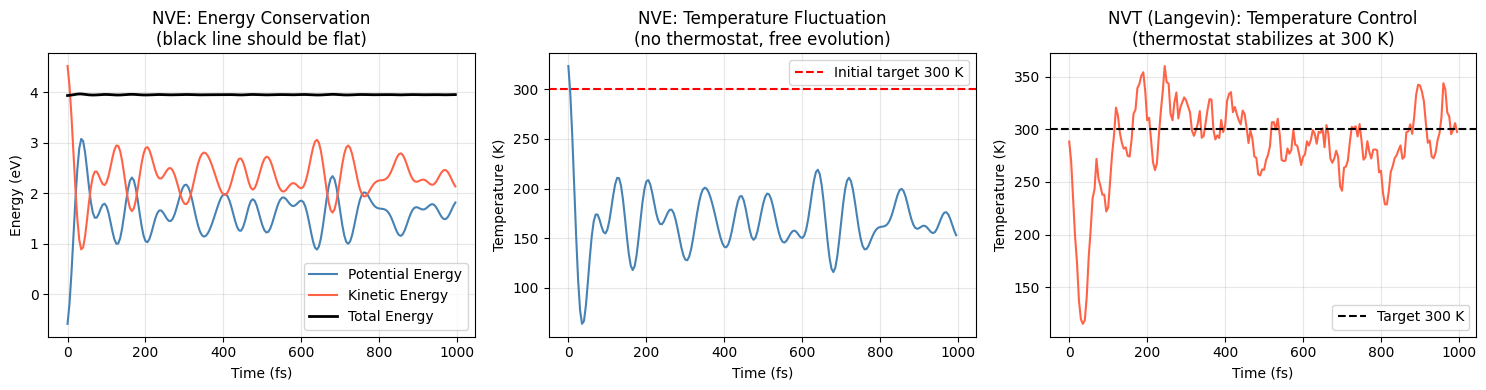

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ase import units                          # ASE 的單位換算模組（eV, fs, Å）
from ase.build import bulk                     # 建立晶體結構的工具
from ase.calculators.emt import EMT            # EMT calculator：計算原子間作用力
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution  # 初始化速度
from ase.md.verlet import VelocityVerlet       # NVE 積分器（Velocity Verlet 算法）
from ase.md.langevin import Langevin           # NVT 積分器（Langevin 熱浴）

# ══════════════════════════════════════════════
# 建立初始結構
# ══════════════════════════════════════════════
# bulk('Cu', 'fcc', a=3.6)：建立銅的 FCC 晶體，晶格常數 3.6 Å
# .repeat(3)：在三個方向各重複 3 次，得到 3×3×3 = 108 個原子的超晶胞
# 原子數要夠多，統計量才有意義
atoms = bulk('Cu', 'fcc', a=3.6, cubic=True).repeat(3)
atoms.calc = EMT()   # 指定用 EMT 計算這個系統的力和能量

T = 300  # 目標溫度，單位 Kelvin（室溫）

# ══════════════════════════════════════════════
# Part 1：NVE — 能量守恆模擬（孤立系統）
# ══════════════════════════════════════════════
atoms_nve = atoms.copy()    # 複製一份，避免 NVE 和 NVT 互相干擾
atoms_nve.calc = EMT()      # 每份複製都需要重新指定 calculator

# Maxwell-Boltzmann 分布：按照 300K 的熱力學分布隨機給每個原子初始速度
# 這只是設定初始條件，系統從這裡開始自由演化
MaxwellBoltzmannDistribution(atoms_nve, temperature_K=T)

# VelocityVerlet：NVE 的數值積分器
# timestep=5*units.fs：每步走 5 飛秒（fs）。步長太大會不穩定，太小會很慢
# Velocity Verlet 是一種時間可逆、能量守恆的算法，適合 NVE
dyn_nve = VelocityVerlet(atoms_nve, timestep=5 * units.fs)

nve_steps = 200   # 跑 200 步，總時間 = 200 × 5 fs = 1000 fs = 1 ps
nve_epot, nve_ekin, nve_etot, nve_temp = [], [], [], []  # 記錄各物理量

for _ in range(nve_steps):
    dyn_nve.run(1)                              # 走一步（更新所有原子的位置和速度）
    epot = atoms_nve.get_potential_energy()     # 位能：來自 EMT calculator
    ekin = atoms_nve.get_kinetic_energy()       # 動能：來自原子速度 E_kin = Σ½mv²
    temp = atoms_nve.get_temperature()          # 溫度：T = 2E_kin / (3Nk_B)
    nve_epot.append(epot)
    nve_ekin.append(ekin)
    nve_etot.append(epot + ekin)               # 總能量 = 位能 + 動能（NVE 下應守恆）
    nve_temp.append(temp)

# ══════════════════════════════════════════════
# Part 2：NVT — Langevin 控溫模擬（恆溫系統）
# ══════════════════════════════════════════════
atoms_nvt = atoms.copy()
atoms_nvt.calc = EMT()
MaxwellBoltzmannDistribution(atoms_nvt, temperature_K=T)

# Langevin thermostat：NVT 積分器
# temperature_K=T：目標溫度 300K
# friction=0.01/units.fs：摩擦係數，控制熱浴耦合強度
#   → 數值越大，溫度收斂越快，但動力學越不真實
#   → 數值越小，更接近真實物理，但收斂慢
# 注意：NVT 下 total energy 不守恆，能量可以和熱浴交換
dyn_nvt = Langevin(atoms_nvt, timestep=5 * units.fs,
                   temperature_K=T, friction=0.01 / units.fs)

nvt_steps = 200
nvt_temp = []

for _ in range(nvt_steps):
    dyn_nvt.run(1)
    nvt_temp.append(atoms_nvt.get_temperature())  # 只記錄溫度，驗證控溫效果

# ══════════════════════════════════════════════
# 畫圖（說明見下方）
# ══════════════════════════════════════════════
time_nve = np.arange(nve_steps) * 5   # 時間軸，單位 fs
time_nvt = np.arange(nvt_steps) * 5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(time_nve, nve_epot, label='Potential Energy', color='steelblue')
axes[0].plot(time_nve, nve_ekin, label='Kinetic Energy', color='tomato')
axes[0].plot(time_nve, nve_etot, label='Total Energy', color='black', linewidth=2)
axes[0].set_xlabel('Time (fs)')
axes[0].set_ylabel('Energy (eV)')
axes[0].set_title('NVE: Energy Conservation\n(black line should be flat)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_nve, nve_temp, color='steelblue')
axes[1].axhline(T, color='red', linestyle='--', label=f'Initial target {T} K')
axes[1].set_xlabel('Time (fs)')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_title('NVE: Temperature Fluctuation\n(no thermostat, free evolution)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_nvt, nvt_temp, color='tomato')
axes[2].axhline(T, color='black', linestyle='--', label=f'Target {T} K')
axes[2].set_xlabel('Time (fs)')
axes[2].set_ylabel('Temperature (K)')
axes[2].set_title('NVT (Langevin): Temperature Control\n(thermostat stabilizes at 300 K)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('md_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3：徑向分布函數（Radial Distribution Function, RDF）

RDF g(r) 的定義：從任意一個原子出發，在距離 r 到 r+dr 的球殼內，
找到另一個原子的機率密度，相對於均勻分布的歸一化值。

$$g(r) = \frac{V}{N^2} \left\langle \sum_{i \neq j} \delta(r - r_{ij}) \right\rangle$$

### 物理意義

| 系統狀態 | RDF 的樣子 |
|---|---|
| 完美晶體（0K）| 幾個無限尖銳的 delta 函數峰 |
| 固體（有限溫度）| 幾個寬化的峰，對應近鄰距離 |
| 液體 | 第一個峰明顯，之後快速衰減到 1 |
| 氣體 | 幾乎沒有結構，g(r) ≈ 1 |

### 對銅（FCC）的預期

FCC 晶體的第一近鄰距離 = a/√2 ≈ 3.6/1.414 ≈ 2.55 Å
RDF 第一個峰應出現在這個位置附近。

Equilibrating...
Collected 50 snapshots


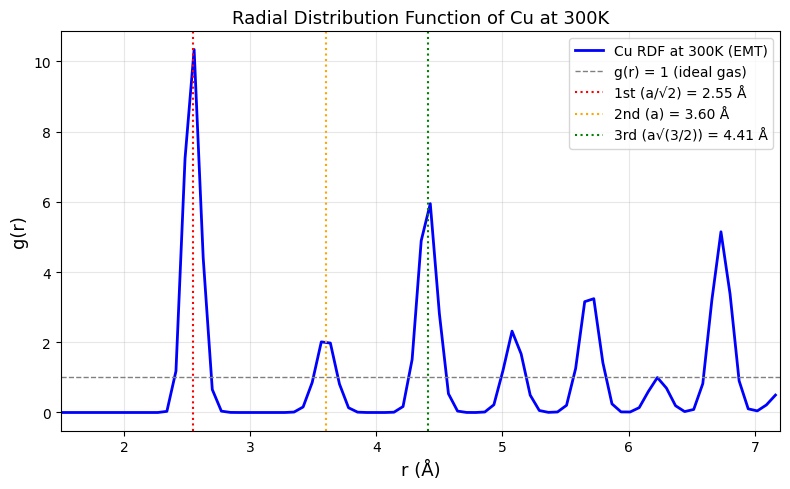

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.calculators.emt import EMT
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet
from ase import units

# ══════════════════════════════════════════════
# 建立並平衡系統（先跑 NVE 讓系統弛豫）
# ══════════════════════════════════════════════
# 用比之前更大的超晶胞，RDF 統計更準確
atoms = bulk('Cu', 'fcc', a=3.6, cubic=True).repeat(4)  # 4×4×4 = 256 原子
atoms.calc = EMT()
MaxwellBoltzmannDistribution(atoms, temperature_K=300)

dyn = VelocityVerlet(atoms, timestep=5 * units.fs)

# 先跑 100 步讓系統平衡（equilibration），這段資料不用來計算 RDF
print("Equilibrating...")
dyn.run(100)

# ══════════════════════════════════════════════
# 收集結構快照，用來計算 RDF
# ══════════════════════════════════════════════
# RDF 需要對多個時間步平均，才能得到統計上穩定的結果
# 就像 DMFT 裡 QMC 需要足夠的 Monte Carlo 步數才能收斂

snapshots = []           # 儲存每個時間步的原子位置
n_collect = 50           # 收集 50 個快照
collect_interval = 5     # 每 5 步收集一次（避免連續快照之間相關性太強）

print("Collecting snapshots for RDF...")
for i in range(n_collect):
    dyn.run(collect_interval)
    snapshots.append(atoms.get_positions().copy())  # 記錄此時所有原子的 xyz 位置

print(f"Collected {len(snapshots)} snapshots")

# ══════════════════════════════════════════════
# 手動計算 RDF
# ══════════════════════════════════════════════
# 原理：對每一對原子 (i,j)，計算距離 r_ij，統計各距離區間的原子對數
# 再除以均勻分布的期望值，得到歸一化的 g(r)

cell = atoms.get_cell()           # 晶胞的形狀（用於週期性邊界條件）
L = cell[0, 0]                    # 假設立方晶胞，取邊長
N = len(atoms)                    # 原子總數
V = L**3                          # 體積（Å³）
rho = N / V                       # 數密度（原子/Å³）

r_max = L / 2                     # 最大計算距離：不超過晶胞一半（避免週期性重複計數）
n_bins = 100                      # 距離分成 100 個區間
dr = r_max / n_bins               # 每個區間的寬度
r_bins = np.linspace(0, r_max, n_bins + 1)   # 區間邊界
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:]) # 每個區間的中心值

rdf_sum = np.zeros(n_bins)        # 累加所有快照的 RDF

for positions in snapshots:
    counts = np.zeros(n_bins)

    for i in range(N):
        for j in range(i + 1, N):
            # 計算原子對 (i,j) 的距離，考慮週期性邊界條件
            dr_vec = positions[i] - positions[j]
            # 最近映像約定（minimum image convention）：
            # 如果距離超過半個晶胞，就取另一側的映像
            dr_vec -= L * np.round(dr_vec / L)
            r = np.sqrt(np.sum(dr_vec**2))

            if r < r_max:
                bin_idx = int(r / dr)
                if bin_idx < n_bins:
                    counts[bin_idx] += 2  # i→j 和 j→i 各算一次

    # 歸一化：除以球殼體積和期望原子數
    # 球殼體積 = 4π r² dr
    # 期望原子數 = rho × 球殼體積 × N
    shell_volumes = 4 * np.pi * r_centers**2 * dr
    rdf_sum += counts / (N * rho * shell_volumes)

# 對所有快照取平均
rdf = rdf_sum / len(snapshots)

# ══════════════════════════════════════════════
# 畫圖
# ══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(r_centers, rdf, 'b-', linewidth=2, label='Cu RDF at 300K (EMT)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='g(r) = 1 (ideal gas)')

# 標出 FCC 的理論近鄰距離
a = 3.6   # 晶格常數 Å
fcc_neighbors = {
    '1st (a/√2)':  a / np.sqrt(2),    # ≈ 2.55 Å，12 個近鄰
    '2nd (a)':     a,                  # ≈ 3.60 Å，6 個近鄰
    '3rd (a√(3/2))': a * np.sqrt(1.5) # ≈ 4.41 Å，24 個近鄰
}

colors_nn = ['red', 'orange', 'green']
for (label, r_nn), col in zip(fcc_neighbors.items(), colors_nn):
    ax.axvline(r_nn, color=col, linestyle=':', linewidth=1.5,
               label=f'{label} = {r_nn:.2f} Å')

ax.set_xlabel('r (Å)', fontsize=13)
ax.set_ylabel('g(r)', fontsize=13)
ax.set_title('Radial Distribution Function of Cu at 300K', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(1.5, r_max)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rdf_cu.png', dpi=150, bbox_inches='tight')
plt.show()